# Probability

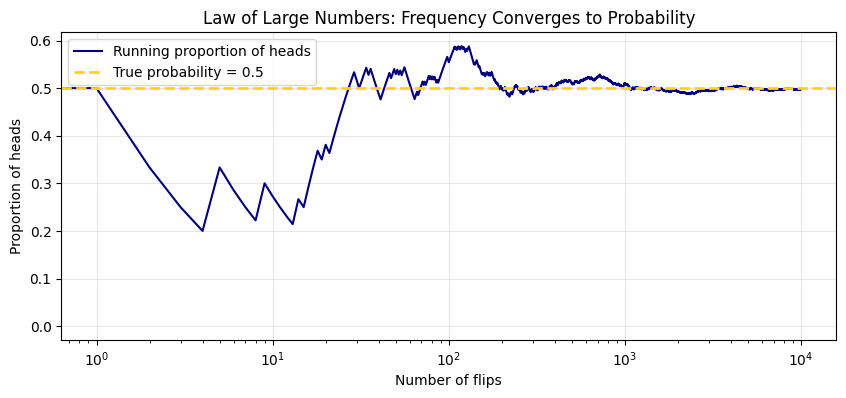

In [3]:
import numpy as np 
import matplotlib.pyplot as plt 
  
# Law of Large Numbers: simulate flipping a fair coin 
np.random.seed(42) 
n_flips = 10000 
flips = np.random.randint(0, 2, n_flips)  # 0=tails, 1=heads 
  
# Compute running average (proportion of heads so far) 
running_mean = np.cumsum(flips) / np.arange(1, n_flips + 1) 
  
plt.figure(figsize=(10, 4)) 
plt.plot(running_mean, color='navy', lw=1.5, label='Running proportion of heads') 
plt.axhline(0.5, color='gold', lw=2, ls='--', label='True probability = 0.5') 
plt.xlabel('Number of flips') 
plt.ylabel('Proportion of heads') 
plt.title('Law of Large Numbers: Frequency Converges to Probability') 
plt.legend() 
plt.grid(True, alpha=0.3) 
plt.xscale('log')   # Log scale to see early fluctuations clearly 
plt.show()

## Addition and Multiplication

In [5]:
import numpy as np 
  
# Simulate a deck of 52 cards 
np.random.seed(0) 
n_draws = 100000 
  
# Draw one card — is it a heart or a king? 
suits  = np.random.randint(1, 5, n_draws)   # 1=hearts, 2=diamonds, 3=clubs, 
spades = 4
values = np.random.randint(1, 14, n_draws)  # 1=Ace through 13=King 
  
is_heart = suits == 1         # P(heart) = 13/52 = 0.25 
is_king  = values == 13       # P(king)  =  4/52 ≈ 0.077 
is_heart_king = is_heart & is_king  # King of hearts: 1/52 ≈ 0.019 
  
print(f'P(heart):         {is_heart.mean():.4f}  (expected: 0.2500)') 
print(f'P(king):          {is_king.mean():.4f}  (expected: 0.0769)') 
print(f'P(heart AND king):{is_heart_king.mean():.4f}  (expected: 0.0192)') 
print(f'P(heart OR  king):{(is_heart | is_king).mean():.4f}  (expected: 0.3077)') 
  
# Verify addition rule: P(A or B) = P(A) + P(B) - P(A and B) 
rule_check = is_heart.mean() + is_king.mean() - is_heart_king.mean() 
print(f'Addition rule check: {rule_check:.4f}')

P(heart):         0.2499  (expected: 0.2500)
P(king):          0.0771  (expected: 0.0769)
P(heart AND king):0.0189  (expected: 0.0192)
P(heart OR  king):0.3081  (expected: 0.3077)
Addition rule check: 0.3081


## conditional probability

In [10]:
import numpy as np 
import pandas as pd 
  
# Simulate a medical test scenario 
# Disease prevalence: 1% of population has it 
# Test sensitivity (True Positive Rate): 95% 
# Test specificity (True Negative Rate): 90% 
  
np.random.seed(1) 
n = 100000 
  
# Ground truth: does the person have the disease? 
has_disease = np.random.random(n) < 0.01   # 1% prevalence 
  
# Test result depends on disease status 
test_positive = np.where( 
    has_disease, 
    np.random.random(n) < 0.95,   # 95% chance of correct positive 
    np.random.random(n) < 0.10    # 10% chance of false positive 
) 
  
# Build a confusion-style table 
df = pd.DataFrame({'disease': has_disease, 'test_pos': test_positive}) 
  
# Conditional probabilities 
p_pos_given_disease    = df[df.disease]['test_pos'].mean() 
p_pos_given_no_disease = df[~df.disease]['test_pos'].mean() 
p_disease_given_pos    = df[df.test_pos]['disease'].mean()  # This is what we 

  
print(f'P(test+ | disease)   = {p_pos_given_disease:.3f}')  # Sensitivity 
print(f'P(test+ | no disease)= {p_pos_given_no_disease:.3f}')  # False pos rate 
print(f'P(disease | test+)   = {p_disease_given_pos:.3f}')  # Positive Predictive 

# Even with a positive test, you may only be ~9% likely to have the disease! 
# This is the base rate fallacy — critical for ML model evaluation.

P(test+ | disease)   = 0.937
P(test+ | no disease)= 0.101
P(disease | test+)   = 0.085


## Bayes' Theorem

In [11]:
# Bayes' theorem: the mathematical engine of belief updating 
  
# Scenario: A spam filter 
# P(spam) = 0.20         — 20% of all emails are spam (prior) 
# P('free' | spam) = 0.60  — 60% of spam contains the word 'free' 
# P('free' | not spam) = 0.05 — only 5% of legitimate emails contain 'free' 
  
p_spam          = 0.20 
p_not_spam      = 0.80 
p_free_spam     = 0.60 
p_free_not_spam = 0.05 
  
# P('free') = P('free'|spam)*P(spam) + P('free'|not_spam)*P(not_spam) 
p_free = p_free_spam * p_spam + p_free_not_spam * p_not_spam 
  
# Bayes: P(spam | 'free') = P('free' | spam) * P(spam) / P('free') 
p_spam_given_free = (p_free_spam * p_spam) / p_free 
  
print(f"P('free'):              {p_free:.3f}") 
print(f"P(spam | 'free'):       {p_spam_given_free:.3f}") 
# Seeing the word 'free' updates spam probability from 0.20 to ~0.75! 
  
# The Naive Bayes classifier applies this for EVERY word in the email 
# and multiplies the probabilities (assuming independence between words)

P('free'):              0.160
P(spam | 'free'):       0.750


## Independence and Dependence

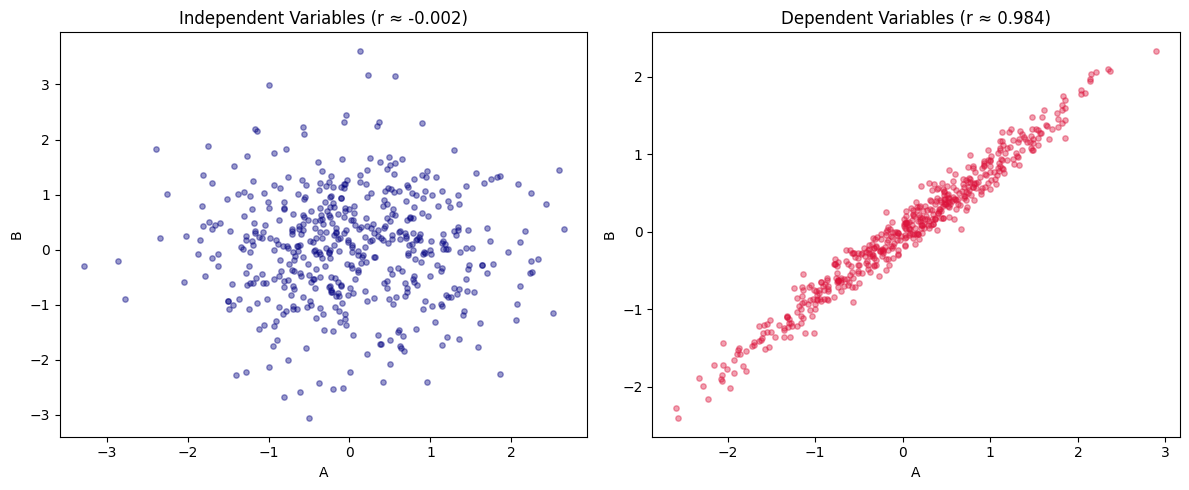

In [14]:
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns


np.random.seed(5) 
n = 500 
  
# Independent variables: knowing A tells you nothing about B 
A_indep = np.random.normal(0, 1, n) 
B_indep = np.random.normal(0, 1, n)   # Completely separate 
  
# Dependent variables: B is partly determined by A 
A_dep = np.random.normal(0, 1, n) 
B_dep = 0.85 * A_dep + 0.15 * np.random.normal(0, 1, n) 
  
fig, axes = plt.subplots(1, 2, figsize=(12, 5)) 
  
axes[0].scatter(A_indep, B_indep, alpha=0.4, color='navy', s=15) 
axes[0].set_title(f'Independent Variables (r ≈ {np.corrcoef(A_indep, 
B_indep)[0,1]:.3f})') 
axes[0].set_xlabel('A'); axes[0].set_ylabel('B') 
  
axes[1].scatter(A_dep, B_dep, alpha=0.4, color='crimson', s=15) 
axes[1].set_title(f'Dependent Variables (r ≈ {np.corrcoef(A_dep, 
B_dep)[0,1]:.3f})') 
axes[1].set_xlabel('A'); axes[1].set_ylabel('B') 
  
plt.tight_layout() 
plt.show()
